In [ ]:
# %pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    balanced_accuracy_score
)

In [3]:
from pipeline.data_pipeline import preprocessor, X, y

In [4]:
# Data splitting into training and test sets
# stratify=y ensures proportional class distribution in train/test, important for imbalanced datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y if isinstance(y, pd.Series) and y.nunique() > 1 and not y.isnull().any() else None
)

In [5]:
# Preprocess the data
# Fit the preprocessor on the training data and transform both training and test data.
# It's assumed that your preprocessor's fit method does not require y.
# If it does for some specific transformer, you might need to pass y_train.
# However, standard practice for preprocessors like OneHotEncoder, StandardScaler is to fit only on X.
print("Fitting preprocessor on X_train...")
preprocessor.fit(X_train) # Fit only on X_train
print("Transforming X_train...")
X_train_processed = preprocessor.transform(X_train)
print("Transforming X_test...")
X_test_processed = preprocessor.transform(X_test)

Fitting preprocessor on X_train...
Transforming X_train...
Transforming X_test...


In [6]:
# Ensure data is float32 for TensorFlow and target is also float32
X_train_processed = np.asarray(X_train_processed).astype('float32')
X_test_processed = np.asarray(X_test_processed).astype('float32')
y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_test).astype('float32')

print(f"Shape of processed X_train: {X_train_processed.shape}")
print(f"Shape of processed X_test: {X_test_processed.shape}")

Shape of processed X_train: (124553, 40)
Shape of processed X_test: (31139, 40)


In [7]:
# Get the number of input features for the NN from the processed data
input_dim = X_train_processed.shape[1]

In [8]:
# Define the Neural Network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),  # Dropout for regularization
    Dense(64, activation='relu'),
    Dropout(0.3),  # Dropout for regularization
    Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification (output between 0 and 1)
])

c:\Users\lol--\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', # Suitable for binary classification problems
              metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Check for NaNs in y_train before training
if pd.Series(y_train).isnull().any():
    print(f"WARNING: y_train contains NaN values ({pd.Series(y_train).isnull().sum()} occurrences). This can lead to errors during training.")

In [11]:
# Train the model
print("Starting model training...")
history = model.fit(X_train_processed, y_train,
                    epochs=20,  # Number of times to iterate over the entire dataset
                    batch_size=32,  # Number of samples per gradient update
                    validation_split=0.1,  # Fraction of the training data to be used as validation data
                    verbose=1)  # Set to 1 to see training progress, 0 for silent

# Evaluate the model on the test set
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"\nGenauigkeit des TensorFlow Modells auf den Testdaten: {accuracy:.4f}")
print(f"Verlust des TensorFlow Modells auf den Testdaten: {loss:.4f}")

Starting model training...
Epoch 1/20
3504/3504 ━━━━━━━━━━━━━━━━━━━━ 3s 612us/step - accuracy: 0.9677 - loss: 0.1293 - val_accuracy: 0.9726 - val_loss: 0.1064
Epoch 2/20
3504/3504 ━━━━━━━━━━━━━━━━━━━━ 2s 587us/step - accuracy: 0.9697 - loss: 0.1136 - val_accuracy: 0.9728 - val_loss: 0.1058
Epoch 3/20
3504/3504 ━━━━━━━━━━━━━━━━━━━━ 2s 601us/step - accuracy: 0.9693 - loss: 0.1111 - val_accuracy: 0.9723 - val_loss: 0.1061
Epoch 4/20
3504/3504 ━━━━━━━━━━━━━━━━━━━━ 2s 586us/step - accuracy: 0.9697 - loss: 0.1103 - val_accuracy: 0.9726 - val_loss: 0.1068
Epoch 5/20
3504/3504 ━━━━━━━━━━━━━━━━━━━━ 2s 599us/step - accuracy: 0.9700 - loss: 0.1097 - val_accuracy: 0.9726 - val_loss: 0.1062
Epoch 6/20
3504/3504 ━━━━━━━━━━━━━━━━━━━━ 2s 602us/step - accuracy: 0.9700 - loss: 0.1089 - val_accuracy: 0.9727 - val_loss: 0.1054
Epoch 7/20
3504/3504 ━━━━━━━━━━━━━━━━━━━━ 2s 587us/step - accuracy: 0.9704 - loss: 0.1081 - val_accuracy: 0.9729 - val_loss: 0.1062
Epoch 8/20
3504/3504 ━━━━━━━━━━━━━━━━━━━━ 2s 605u

# Generate Predictions

In [13]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba = model.predict(X_test_processed)

# Convert probabilities to binary class labels (0 or 1) using a 0.5 threshold
y_pred_labels = (y_pred_proba > 0.5).astype(int)

# Ensure y_test is also in the correct format (it should be from previous steps)
# y_test = np.asarray(y_test).astype(int) # Should already be float32, but int for metrics

974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 282us/step


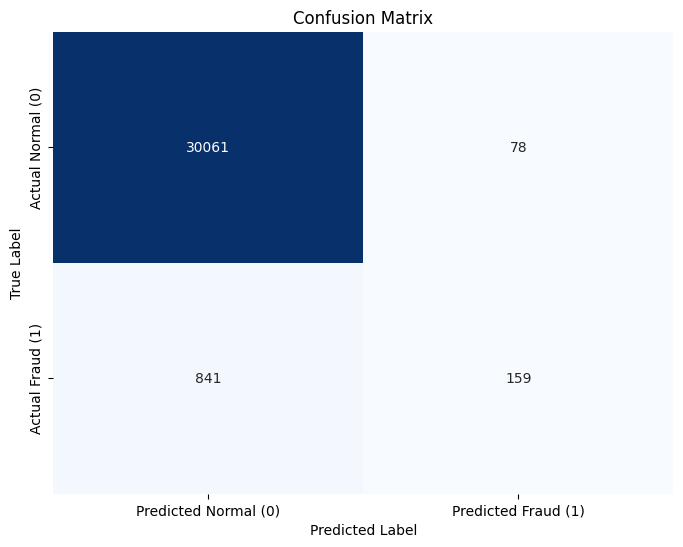

True Negatives (TN) - Correctly predicted Normal: 30061
False Positives (FP) - Incorrectly predicted Fraud (Type I Error): 78
False Negatives (FN) - Incorrectly predicted Normal (Type II Error): 841
True Positives (TP) - Correctly predicted Fraud: 159


In [14]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal (0)', 'Predicted Fraud (1)'],
            yticklabels=['Actual Normal (0)', 'Actual Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# For clarity, extract TP, TN, FP, FN
# Assuming class 1 ('FRAUD') is the positive class
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN) - Correctly predicted Normal: {tn}")
print(f"False Positives (FP) - Incorrectly predicted Fraud (Type I Error): {fp}")
print(f"False Negatives (FN) - Incorrectly predicted Normal (Type II Error): {fn}")
print(f"True Positives (TP) - Correctly predicted Fraud: {tp}")

In [15]:
# Generate the classification report
# Ensure target_names reflect your class labels if they are not 0 and 1 by default in the report
report = classification_report(y_test, y_pred_labels, target_names=['Normal (0)', 'Fraud (1)'])
print("Classification Report:\n")
print(report)

# Calculate Balanced Accuracy
bal_acc = balanced_accuracy_score(y_test, y_pred_labels)
print(f"\nBalanced Accuracy: {bal_acc:.4f}")

Classification Report:

              precision    recall  f1-score   support

  Normal (0)       0.97      1.00      0.98     30139
   Fraud (1)       0.67      0.16      0.26      1000

    accuracy                           0.97     31139
   macro avg       0.82      0.58      0.62     31139
weighted avg       0.96      0.97      0.96     31139


Balanced Accuracy: 0.5782


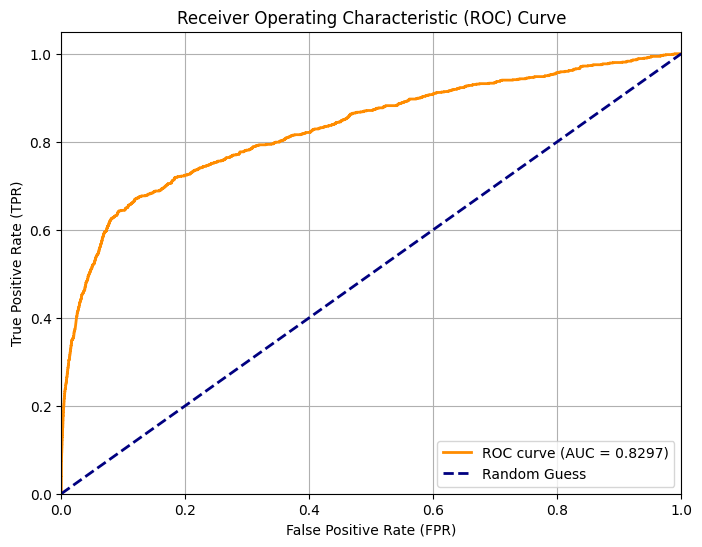

AUC-ROC Score: 0.8297


In [16]:
# Calculate ROC curve and AUC-ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC-ROC Score: {roc_auc:.4f}")

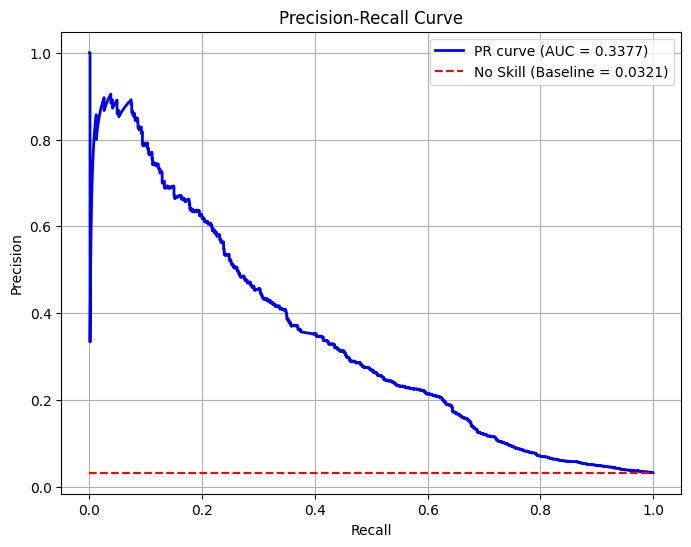

AUC-PR Score (Average Precision): 0.3377


In [17]:
# Calculate Precision-Recall curve and AUC-PR
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
# Calculate the no-skill line (baseline)
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='red', label=f'No Skill (Baseline = {no_skill:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="best")
plt.grid(True)
plt.show()

print(f"AUC-PR Score (Average Precision): {pr_auc:.4f}")

## Understanding Model Evaluation with Imbalanced Data

You've noticed a huge disproportion between 0 and 1 values in your `y` data, which is common in scenarios like fraud detection, medical diagnosis, etc. Here's how to interpret the metrics and common strategies for handling this:

**Why Standard Accuracy Can Be Misleading:**
If 99% of your data is 'Normal' (class 0) and only 1% is 'Fraud' (class 1), a model that always predicts 'Normal' would achieve 99% accuracy. However, it would be useless for detecting fraud. This is why we need more nuanced metrics.

**Key Metrics for Imbalanced Datasets:**

* **Confusion Matrix**:
    * **True Positives (TP)**: Fraud cases correctly identified as Fraud.
    * **False Positives (FP)**: Normal cases incorrectly identified as Fraud (Type I error).
    * **True Negatives (TN)**: Normal cases correctly identified as Normal.
    * **False Negatives (FN)**: Fraud cases incorrectly identified as Normal (Type II error - often the most critical error in fraud detection).
* **Precision (for the positive class, e.g., 'Fraud')**: `TP / (TP + FP)`
    * Of all instances predicted as Fraud, how many were actually Fraud? High precision means fewer false alarms.
* **Recall (Sensitivity, True Positive Rate - TPR) (for 'Fraud')**: `TP / (TP + FN)`
    * Of all actual Fraud instances, how many did the model correctly identify? High recall means fewer missed fraud cases.
* **F1-Score (for 'Fraud')**: `2 * (Precision * Recall) / (Precision + Recall)`
    * The harmonic mean of Precision and Recall. Useful when you need a balance between them.
* **Balanced Accuracy**: `(Recall_class_0 + Recall_class_1) / 2` or `(TPR + Specificity) / 2`
    * The average of recall for each class. It's a better indicator of overall performance on imbalanced data than raw accuracy.
* **AUC-ROC (Area Under the ROC Curve)**:
    * Measures the model's ability to discriminate between positive and negative classes across all classification thresholds. An AUC of 1.0 is perfect, 0.5 is random.
* **AUC-PR (Area Under the Precision-Recall Curve)**:
    * Often more informative than AUC-ROC for highly imbalanced datasets, especially when the positive class is rare. It focuses on the performance on the minority (positive) class. A higher AUC-PR is better. The baseline is the fraction of positives.

**How to Handle Class Imbalance:**

1.  **Collect More Data**: If feasible, collecting more data for the minority class is often the best solution, though usually difficult.

2.  **Data-Level Approaches (Resampling)**:
    * **Oversampling the Minority Class**:
        * Randomly duplicate samples from the minority class.
        * **SMOTE (Synthetic Minority Over-sampling Technique)**: Creates synthetic samples for the minority class rather than just duplicating, which can be more effective.
    * **Undersampling the Majority Class**:
        * Randomly remove samples from the majority class. This can lead to loss of information.
    * **Combination of Oversampling and Undersampling**.

3.  **Algorithm-Level Approaches (Cost-Sensitive Learning)**:
    * Assign different weights to misclassifications. For example, penalize misclassifying a 'Fraud' instance (FN) more heavily than misclassifying a 'Normal' instance (FP).
    * In Keras, you can use the `class_weight` parameter in `model.fit()`. You would typically assign a higher weight to the minority class.

4.  **Choosing Appropriate Evaluation Metrics**: As done above, focus on metrics like Precision, Recall, F1-score, Balanced Accuracy, and AUC-PR rather than just overall accuracy.

5.  **Threshold Moving**:
    * The default threshold for converting probabilities to class labels is 0.5. For imbalanced datasets, this might not be optimal.
    * You can analyze the ROC curve or PR curve to choose a threshold that balances Precision and Recall according to your specific needs (e.g., maximize F1-score, or achieve a certain Recall level).

6.  **Using Different Algorithms**: Some algorithms are inherently better at handling imbalance or can be adapted for it (e.g., tree-based methods like Random Forest or Gradient Boosting often perform well, and some have built-in mechanisms or parameters for imbalance).

7.  **Anomaly Detection**: If the minority class is extremely rare and represents "anomalous" behavior, framing the problem as anomaly detection might be more appropriate.

The choice of strategy depends on the dataset, the problem, and the specific goals (e.g., is it more critical to minimize false negatives or false positives?). It often involves experimentation.